# 03 Model Inspection

This notebook is being built as a step-by-step model inspection guide.

Section 0 starts with a tiny PyTorch refresher. The later sections then use the same ideas to inspect `AutoencoderExcitedMACE`: modules, parameters, forward passes, and loss objects.

## 0. PyTorch Preliminaries

Before inspecting X-MACE, it helps to remember the basic PyTorch pattern: subclass `nn.Module`, define trainable layers in `__init__`, define the computation in `forward`, then call the model like a normal function.

In [1]:
import os
import numpy as np
import torch
from torch import nn
from e3nn import o3

import mace
from mace import modules

DEVICE = torch.device("cpu")
torch.set_default_dtype(torch.float64)

print("DEVICE:", DEVICE)

DEVICE: cpu


### 0.1 Lego Blocks: Individual Layers

A neural network layer is a subclass of `nn.Module`. Models are separated to tiny lego blocks, usually separated by stages because they have different functions and look different. In this example, we only use two linear layers so its abit pointless but for X-MACE this idea becomes important

In [2]:
class TinyLayer1(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()

        # This is a trainable layer: weight and bias are created here.
        self.linear = nn.Linear(input_dim, hidden_dim)
        self.activation = nn.SiLU()

    def forward(self, x):
        # This layer maps input features into hidden features.
        x = self.linear(x)
        x = self.activation(x)
        return x


class TinyLayer2(nn.Module):
    def __init__(self, hidden_dim, output_dim):
        super().__init__()

        # This is another trainable layer.
        self.linear = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # This layer maps hidden features into output features.
        x = self.linear(x)
        return x

### 0.2 Lego Blocks: Compose A Model

A full model is also an `nn.Module`. It is defined by joining other smaller layer blocks together. 
This is the same pattern used by X-MACE: the full model owns embedding blocks, interaction blocks, product blocks, readouts, encoder, and decoder.
The forward layer determines how the information flows between blocks

In [3]:
class TinyModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()

        # These submodules are now registered inside the full model.
        self.layer_1 = TinyLayer1(input_dim, hidden_dim)
        self.layer_2 = TinyLayer2(hidden_dim, output_dim)

    def forward(self, x):
        # The forward pass defines the order of the Lego blocks.
        x = self.layer_1(x)
        x = self.layer_2(x)
        return x

"""
Importantly, the output of layer 1 and input of layer 2 must match here exactly 
In this minimal model, a 3 dimension vector maps to a 5 dimension vector in layer 1. 
This 5D vector then gets passed into layer 2. This 5D vector then gets mapped to a 2D output

This means that the model would expect an input that has 3 features, and will output
2 numbers. 
"""

tiny_model = TinyModel(input_dim=3, hidden_dim=5, output_dim=2).to(DEVICE)

print(tiny_model)
print("\nNamed parameters:")
for name, parameter in tiny_model.named_parameters():
    print(f"{name:24s} shape={tuple(parameter.shape)} trainable={parameter.requires_grad}")

TinyModel(
  (layer_1): TinyLayer1(
    (linear): Linear(in_features=3, out_features=5, bias=True)
    (activation): SiLU()
  )
  (layer_2): TinyLayer2(
    (linear): Linear(in_features=5, out_features=2, bias=True)
  )
)

Named parameters:
layer_1.linear.weight    shape=(5, 3) trainable=True
layer_1.linear.bias      shape=(5,) trainable=True
layer_2.linear.weight    shape=(2, 5) trainable=True
layer_2.linear.bias      shape=(2,) trainable=True


### 0.3 Forward Pass And One Training Step

A forward pass produces predictions. A loss compares predictions to targets. `loss.backward()` computes gradients, and `optimizer.step()` updates trainable parameters.

In [4]:
# One tiny batch: 4 samples, each with 3 input features.
x = torch.randn(4, 3, device=DEVICE)
y = torch.randn(4, 2, device=DEVICE)

optimizer = torch.optim.Adam(tiny_model.parameters(), lr=1.0e-3)
loss_fn = nn.MSELoss()

# 1. Clear old gradients.
optimizer.zero_grad(set_to_none=True)

# 2. Forward pass: this calls tiny_model.forward(x).
prediction = tiny_model(x)

# 3. Compute scalar loss.
loss = loss_fn(prediction, y)

# 4. Backward pass: fill parameter.grad for every trainable parameter.
loss.backward()

# 5. Optimizer step: update weights using the gradients.
optimizer.step()

print("x shape:", tuple(x.shape))
print("prediction shape:", tuple(prediction.shape))
print("target shape:", tuple(y.shape))
print("loss:", float(loss.detach().cpu()))

print("\nGradient shapes after backward:")
for name, parameter in tiny_model.named_parameters():
    print(f"{name:20s} grad_shape={tuple(parameter.grad.shape)}")

x shape: (4, 3)
prediction shape: (4, 2)
target shape: (4, 2)
loss: 0.31761010570992587

Gradient shapes after backward:
layer_1.linear.weight grad_shape=(5, 3)
layer_1.linear.bias  grad_shape=(5,)
layer_2.linear.weight grad_shape=(2, 5)
layer_2.linear.bias  grad_shape=(2,)


## 1. X-MACE Overview

`AutoencoderExcitedMACE` is also an `nn.Module`. It is comprised of smaller layer blocks (also nn.Module objects). However, not every layer has trainable parameters. Some layers are just math functions that map an input to an output. All these are defined in the forward layer. 

The main AutoencoderExcitedMAce class is defined in:

```text
mace/modules/models.py
```
This subsequent tutorial seeks to explore each individual layer of the model and explicitly learn about the dimensions and features of it.

This is focused on the energy-only autoencoder path. Optional NAC, SOC are not discussed 

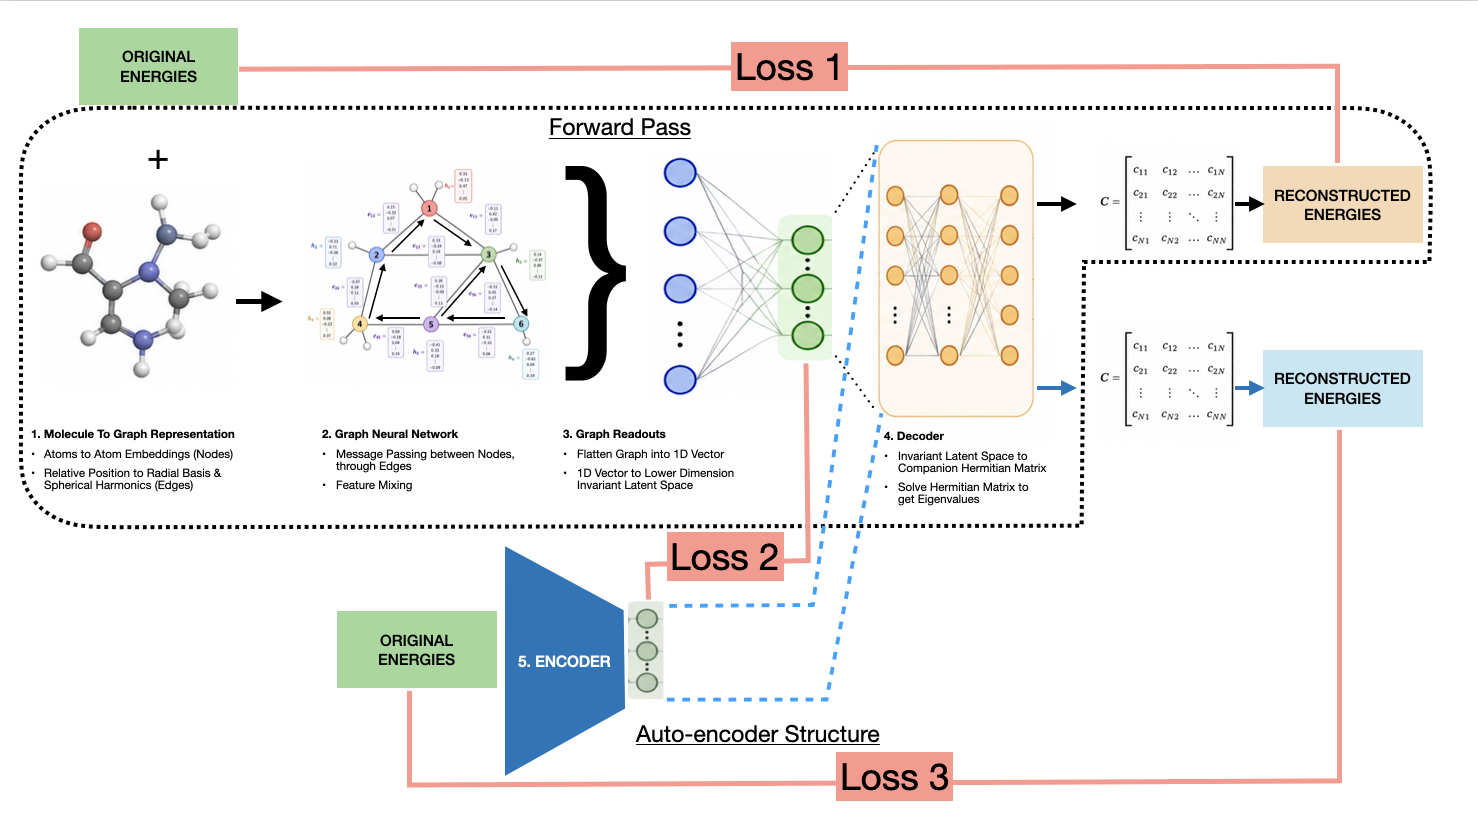

### Main blocks of X-MACE

The key stages of the X-MACE forward pass are as follows
1. Molecule to Graph Representation 
- Atoms are converted to embedding vectors via learned parameters
- Distance between atoms are converted to radial basis and spherical harmonics via two math mapping blocks. These are NOT trained layers, but pre defined function layers. These act as the edge vectors 

2. Graph Neural Network
- Each atom (node) passes messages to surrounding atoms a few times across the edges that connect them 
- Every message passing step allows atoms to learn about each other 

3. Graph Readouts 
- The final "learned" node vectors are first flattened into a high dimensional vector
- This gets mapped to an invariant low dimensional latent space 

4. Decoder 
- Decoder takes in the latent space vector, and maps it into a few matrix elements
- This will be the coefficients of the hermitian companion matrix. Diagonalising this matrix will give the n excited states 

Additionally, X-MACE uses an encoder to help to guide the training of this model. This is built on the assumption that there is a low dimensional latent space that can capture the energies and excited states well. 

The encoder is part of the model object, but it is not called inside `AutoencoderExcitedMACE.forward`. During training, the training loop separately sends the reference energies through the encoder, then compares that encoded latent target to the GNN-produced latent vector.
This is used to guide the loss, such that the latent space is something that can be reached by the GNN and something that can be encoded directly from the energies. 

The GNN, invariant readout, encoder, and decoder weights are optimized together during each training step.

## 2. Molecule to Graph Conversion

Before the GNN can do message passing, the molecule needs to be represented as graph tensors. In the real training pipeline, X-MACE builds these tensors from `ase.Atoms` objects and dataloaders. Here we manually build a tiny three-atom example so the dimensions are visible.

### 2.1 Atomic Embeddings

Each atom first becomes a one-hot vector called `node_attrs`. The columns are the allowed element types. In this tiny example, the allowed elements are `C` and `H`, so carbon is `[1, 0]` and hydrogen is `[0, 1]`.

`LinearNodeEmbeddingBlock` then maps those one-hot atom identities into learned node features. This is the first trainable part of the model: changing these weights changes the initial vector assigned to each element type.


In [5]:
# Tiny molecule used throughout Section 2.
toy_symbols = ["C", "H", "H"]
element_symbols = ["C", "H"]
element_to_column = {symbol: column for column, symbol in enumerate(element_symbols)}

# node_attrs has one row per atom and one column per allowed element type.
node_attrs = torch.zeros(
    (len(toy_symbols), len(element_symbols)),
    dtype=torch.get_default_dtype(),
    device=DEVICE,
)
for atom_index, symbol in enumerate(toy_symbols):
    node_attrs[atom_index, element_to_column[symbol]] = 1.0

# This mirrors the construction inside AutoencoderExcitedMACE.__init__.
hidden_irreps = o3.Irreps("4x0e + 4x1o")
node_attr_irreps = o3.Irreps([(len(element_symbols), (0, 1))])
node_feats_irreps = o3.Irreps([(hidden_irreps.count(o3.Irrep(0, 1)), (0, 1))])

node_embedding = modules.LinearNodeEmbeddingBlock(
    irreps_in=node_attr_irreps,
    irreps_out=node_feats_irreps,
).to(DEVICE)

node_feats = node_embedding(node_attrs)

print("toy_symbols:", toy_symbols)
print("element columns:", element_to_column)
print("node_attrs shape:", tuple(node_attrs.shape))
print(node_attrs)
print("\nnode_embedding:")
print(node_embedding)
print("\nTrainable parameters:")
for name, parameter in node_embedding.named_parameters():
    print(f"{name:24s} shape={tuple(parameter.shape)} trainable={parameter.requires_grad}")
print("\nnode_feats shape:", tuple(node_feats.shape))
print(node_feats)


toy_symbols: ['C', 'H', 'H']
element columns: {'C': 0, 'H': 1}
node_attrs shape: (3, 2)
tensor([[1., 0.],
        [0., 1.],
        [0., 1.]])

node_embedding:
LinearNodeEmbeddingBlock(
  (linear): Linear(2x0e -> 4x0e | 8 weights)
)

Trainable parameters:
linear.weight            shape=(8,) trainable=True

node_feats shape: (3, 4)
tensor([[-0.1126,  0.5284, -0.3700, -0.1514],
        [ 1.2690,  0.5651, -0.2501,  0.1199],
        [ 1.2690,  0.5651, -0.2501,  0.1199]], grad_fn=<ViewBackward0>)


/opt/miniconda3/envs/mlip/lib/python3.13/ast.py:428: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)


### 2.2 Radial Basis

The graph also needs edges. Each directed edge says which atom is sending information to which other atom. From atom positions and `edge_index`, X-MACE computes an edge vector and an edge length.

The radial basis maps each scalar distance into several distance features. This lets the later interaction block learn different behavior for short, medium, and long distances instead of seeing only one raw distance number.


In [6]:
from mace.modules.utils import get_edge_vectors_and_lengths

# Simple 2D geometry written in 3D coordinates.
positions = torch.tensor(
    [
        [0.00, 0.00, 0.00],
        [1.09, 0.00, 0.00],
        [-0.36, 1.03, 0.00],
    ],
    dtype=torch.get_default_dtype(),
    device=DEVICE,
)

# Directed edges: 0->1 and 1->0 are different message directions.
edge_index = torch.tensor(
    [
        [0, 1, 0, 2, 1, 2],
        [1, 0, 2, 0, 2, 1],
    ],
    dtype=torch.long,
    device=DEVICE,
)
shifts = torch.zeros((edge_index.shape[1], 3), dtype=torch.get_default_dtype(), device=DEVICE)

vectors, lengths = get_edge_vectors_and_lengths(
    positions=positions,
    edge_index=edge_index,
    shifts=shifts,
)

radial_embedding = modules.RadialEmbeddingBlock(
    r_max=3.0,
    num_bessel=4,
    num_polynomial_cutoff=5,
    radial_type="bessel",
    distance_transform="None",
).to(DEVICE)

# atomic_numbers is unused here because distance_transform="None", but the real model passes it in.
atomic_numbers = torch.tensor([6, 1], dtype=torch.long, device=DEVICE)
edge_feats = radial_embedding(lengths, node_attrs, edge_index, atomic_numbers)

edge_pairs = [
    f"{int(sender)}({toy_symbols[int(sender)]}) -> {int(receiver)}({toy_symbols[int(receiver)]})"
    for sender, receiver in edge_index.T
]

print("edge list:")
for edge_id, label in enumerate(edge_pairs):
    print(f"edge {edge_id}: {label}")
print("\nvectors shape:", tuple(vectors.shape))
print(vectors)
print("\nlengths shape:", tuple(lengths.shape))
print(lengths.squeeze(-1))
print("\nradial_embedding:")
print(radial_embedding)
print("\nedge_feats shape:", tuple(edge_feats.shape))
print(edge_feats[:3])


edge list:
edge 0: 0(C) -> 1(H)
edge 1: 1(H) -> 0(C)
edge 2: 0(C) -> 2(H)
edge 3: 2(H) -> 0(C)
edge 4: 1(H) -> 2(H)
edge 5: 2(H) -> 1(H)

vectors shape: (6, 3)
tensor([[ 1.0900,  0.0000,  0.0000],
        [-1.0900,  0.0000,  0.0000],
        [-0.3600,  1.0300,  0.0000],
        [ 0.3600, -1.0300,  0.0000],
        [-1.4500,  1.0300,  0.0000],
        [ 1.4500, -1.0300,  0.0000]])

lengths shape: (6, 1)
tensor([1.0900, 1.0900, 1.0911, 1.0911, 1.7786, 1.7786])

radial_embedding:
RadialEmbeddingBlock(
  (bessel_fn): BesselBasis(r_max=3.0, num_basis=4, trainable=False)
  (cutoff_fn): PolynomialCutoff(p=5.0, r_max=3.0)
)

edge_feats shape: (6, 4)
tensor([[ 0.6368,  0.5302, -0.1954, -0.6929],
        [ 0.6368,  0.5302, -0.1954, -0.6929],
        [ 0.6363,  0.5285, -0.1975, -0.6924]])


### 2.3 Spherical Harmonics

Radial features describe **how far** two atoms are from each other. Spherical harmonics describe **which direction** the edge points in.

This directional information is what lets the model be equivariant: if the molecule rotates, the internal directional features rotate in a consistent mathematical way instead of becoming arbitrary features.


In [7]:
max_ell = 2
sh_irreps = o3.Irreps.spherical_harmonics(max_ell)
spherical_harmonics = o3.SphericalHarmonics(
    sh_irreps,
    normalize=True,
    normalization="component",
).to(DEVICE)

edge_attrs = spherical_harmonics(vectors)

print("max_ell:", max_ell)
print("spherical harmonic irreps:", sh_irreps)
print("number of angular channels:", sh_irreps.dim)
print("spherical_harmonics module:")
print(spherical_harmonics)
print("\nedge_attrs shape:", tuple(edge_attrs.shape))
print(edge_attrs[:3])


max_ell: 2
spherical harmonic irreps: 1x0e+1x1o+1x2e
number of angular channels: 9
spherical_harmonics module:
SphericalHarmonics()

edge_attrs shape: (6, 9)
tensor([[ 1.0000,  1.7321,  0.0000,  0.0000,  0.0000,  0.0000, -1.1180,  0.0000,
         -1.9365],
        [ 1.0000, -1.7321,  0.0000,  0.0000, -0.0000, -0.0000, -1.1180,  0.0000,
         -1.9365],
        [ 1.0000, -0.5715,  1.6351,  0.0000, -0.0000, -1.2063,  1.8709,  0.0000,
         -0.2108]])


### 2.4 Net Summary Of The Graph

At this point, the molecule has been converted into the main graph tensors needed before message passing.

- `node_attrs`: atom identity as one-hot vectors
- `node_feats`: learned atom embeddings from `node_attrs`
- `edge_index`: directed graph connectivity
- `vectors`: directed relative positions between atoms
- `lengths`: scalar distances for each directed edge
- `edge_feats`: radial distance features
- `edge_attrs`: angular direction features from spherical harmonics

The next GNN section uses these node and edge tensors to let atoms exchange information.


In [8]:
graph_summary = [
    ("node_attrs", "atom identity one-hot vectors", node_attrs),
    ("node_feats", "learned atom embedding vectors", node_feats),
    ("edge_index", "directed graph connectivity", edge_index),
    ("vectors", "directed relative position vectors", vectors),
    ("lengths", "edge distances", lengths),
    ("edge_feats", "radial distance basis features", edge_feats),
    ("edge_attrs", "spherical harmonic direction features", edge_attrs),
]

print(f"{'tensor':14s} {'shape':18s} meaning")
print("-" * 72)
for name, meaning, tensor in graph_summary:
    print(f"{name:14s} {str(tuple(tensor.shape)):18s} {meaning}")


tensor         shape              meaning
------------------------------------------------------------------------
node_attrs     (3, 2)             atom identity one-hot vectors
node_feats     (3, 4)             learned atom embedding vectors
edge_index     (2, 6)             directed graph connectivity
vectors        (6, 3)             directed relative position vectors
lengths        (6, 1)             edge distances
edge_feats     (6, 4)             radial distance basis features
edge_attrs     (6, 9)             spherical harmonic direction features


## 3. GNN: Message Passing And Product

The GNN part is made of edge features, interaction blocks, and product blocks. The interaction block is where neighbor information is gathered. The product block then mixes the equivariant features into the target hidden representation.

## 4. Invariant Readout

The invariant readout is the branch that maps learned atom features into the autoencoder latent variables. These latent variables are later decoded into electronic-state energies.

## 5. Decoder

The decoder maps the latent invariant vector into `N_ENERGIES` electronic-state energies. In this implementation it predicts the values of a symmetric tridiagonal matrix, then returns sorted eigenvalues.

## 6. Encoder

The encoder maps reference energies into the same latent invariant space. It is part of the autoencoder loss path, not the main model forward path.

## 7. Loss Function

The loss object has no learnable layers, but it decides which model outputs must exist during training. This is important because the encoder/decoder auxiliary tensors are added outside the model forward pass.

## 8. Full Model Parameter And Buffer Tables

This section is the fastest way to see every trainable tensor name and shape. It is useful when deciding what to freeze, replace, or wrap with an adapter layer.

## 9. Where You Might Modify Or Add Layers

This final map is only a guide. It connects architectural locations to the kinds of changes they would affect.